# GridSmart, Stage 2c: Operator Dashboard

**Consuming the forecast topics and visualising them for a grid operator.**

Three views, each answering a question the operator actually asks:

1. **Per-building 6-hour totals**, where is demand concentrated in the next
   dispatch window?
2. **Per-site daily totals**, how much generation does each site need
   scheduled?
3. **Shortfall / excess per site**, where is the forecast wrong, and in
   which direction?

The third is the one that matters most operationally, and it is the hardest
to build: it joins the live predicted stream against actual metered
consumption from a static file, which means reconciling two different
timestamp conventions before the difference means anything.

The value is **signed, not absolute**. Positive means the model
over-forecast and the operator would have generated surplus; negative means a
shortfall, which in a real grid is the expensive direction, met by spinning
up peaking plant or, at the limit, by shedding load. The operator needs to
know *which way* the error points, not just its size.

In [ ]:
# Shared project modules, imported, not redefined. The streaming job and the
# batch trainer use the same feature contract and schemas by construction.
import sys

sys.path.insert(0, "../src")

from gridsmart import config, features, producer, schemas, session, streaming

print(f"Kafka broker : {config.KAFKA_BOOTSTRAP}")
print(f"Topic in     : {config.TOPIC_WEATHER_IN}")
print(f"Cadence      : {config.BATCH_SIZE} records every {config.TICK_SECONDS}s")
print(f"Watermark    : {config.WATERMARK_DELAY} on event time")

## Prerequisites

`02_kafka_producer.ipynb` and `03_spark_streaming.ipynb` must both be running.
This notebook consumes the topics the streaming job publishes:

- `predictions_stream`
- `sixhour_totals_stream`
- `daily_totals_stream`

#### Spark Session Initialization
Before starting any consumer or visualization task, we must initialize a **Spark session**.  
A Spark session is the entry point for any PySpark application. It allows us to:
- Create and manipulate **DataFrames**.
- Connect to **Kafka** for streaming consumption.
- Run **SQL queries**, transformations, and visualizations.
- Configure session-level options (e.g., automatic schema inference).

The code below sets up a Spark session configured for structured streaming with automatic schema detection.

In [1]:
# -----------------------------------------------
# Spark Session Initialization
# -----------------------------------------------

# Import the SparkSession class from PySpark
from pyspark.sql import SparkSession

# Create or retrieve an existing SparkSession.
spark = (
    SparkSession.builder
        .appName("A2B_Part3_Consumer_Visualization")   # Name shown in Spark web UI
        .config("spark.sql.streaming.schemaInference", "true")  # Enables schema auto-inference for streaming
        .getOrCreate()
)

# Confirmation message
print("Spark session created successfully.")

# Optional: Show Spark session details to verify configuration
spark

Spark session created successfully.


## 1. Actual metered consumption

Loaded as a static frame. This is ground truth, what the buildings really
drew. And it is what the predicted totals are measured against in section 3.

In [2]:
# === Q1: Load the new_meters.csv file into a DataFrame ===
from pyspark.sql import SparkSession, types as T

# Define the path to the dataset (adjust if needed)
METERS_PATH = "dataset/new_meters.csv"

# Define schema exactly as in the assignment example
meters_schema = T.StructType([
    T.StructField("building_id", T.IntegerType(), True),
    T.StructField("meter_type",  T.StringType(),  True),
    T.StructField("ts",          T.TimestampType(), True),
    T.StructField("value",       T.DoubleType(),  True),
    T.StructField("row_id",      T.IntegerType(), True)
])

# Load the dataset
meters_df = (
    spark.read
        .option("header", True)
        .schema(meters_schema)
        .csv(METERS_PATH)
)

# Print schema to verify structure
print("=== Schema of new_meters.csv ===")
meters_df.printSchema()

# Show first few rows for inspection
print("=== Loaded data sample ===")
meters_df.show(10, truncate=False)

# Count rows for confirmation
total_rows = meters_df.count()
print(f"Successfully loaded {total_rows} records from {METERS_PATH}")

=== Schema of new_meters.csv ===
root
 |-- building_id: integer (nullable = true)
 |-- meter_type: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- value: double (nullable = true)
 |-- row_id: integer (nullable = true)

=== Loaded data sample ===
+-----------+----------+-------------------+-------+------+
|building_id|meter_type|ts                 |value  |row_id|
+-----------+----------+-------------------+-------+------+
|163        |c         |2022-01-01 00:00:00|4.5719 |3     |
|170        |c         |2022-01-01 00:00:00|11.2891|8     |
|171        |c         |2022-01-01 00:00:00|0.0    |9     |
|172        |c         |2022-01-01 00:00:00|0.0    |10    |
|174        |c         |2022-01-01 00:00:00|52.8583|12    |
|175        |c         |2022-01-01 00:00:00|116.337|13    |
|179        |c         |2022-01-01 00:00:00|0.0703 |17    |
|188        |c         |2022-01-01 00:00:00|6.1545 |22    |
|191        |c         |2022-01-01 00:00:00|82.8922|25    |
|194        |c 

#### **1. Load the New Meters Dataset**

- **Purpose:** Provides actual new metered energy readings for each building to compare against predicted values.  
- **Process:** Loaded `new_meters.csv` using a predefined schema with columns, `building_id`, `meter_type`, `ts`, `value`, and `row_id`. 
- **Function:** Enables calculation of real-time shortfall or excess (`Predicted - Metered`) during Kafka streaming.  
- **Validation:** Schema verified, sample rows inspected, and total records (~6.39M) confirmed for completeness.  
- **Outcome:** Successfully created a reliable reference DataFrame for live visualisation and accuracy checks.

## 2. Live forecast views

Charts refresh as new messages arrive on each topic, at the cadence the
streaming job publishes them (7 s for 6-hour totals, 14 s for daily site
totals).


[6b] Stopped by user.


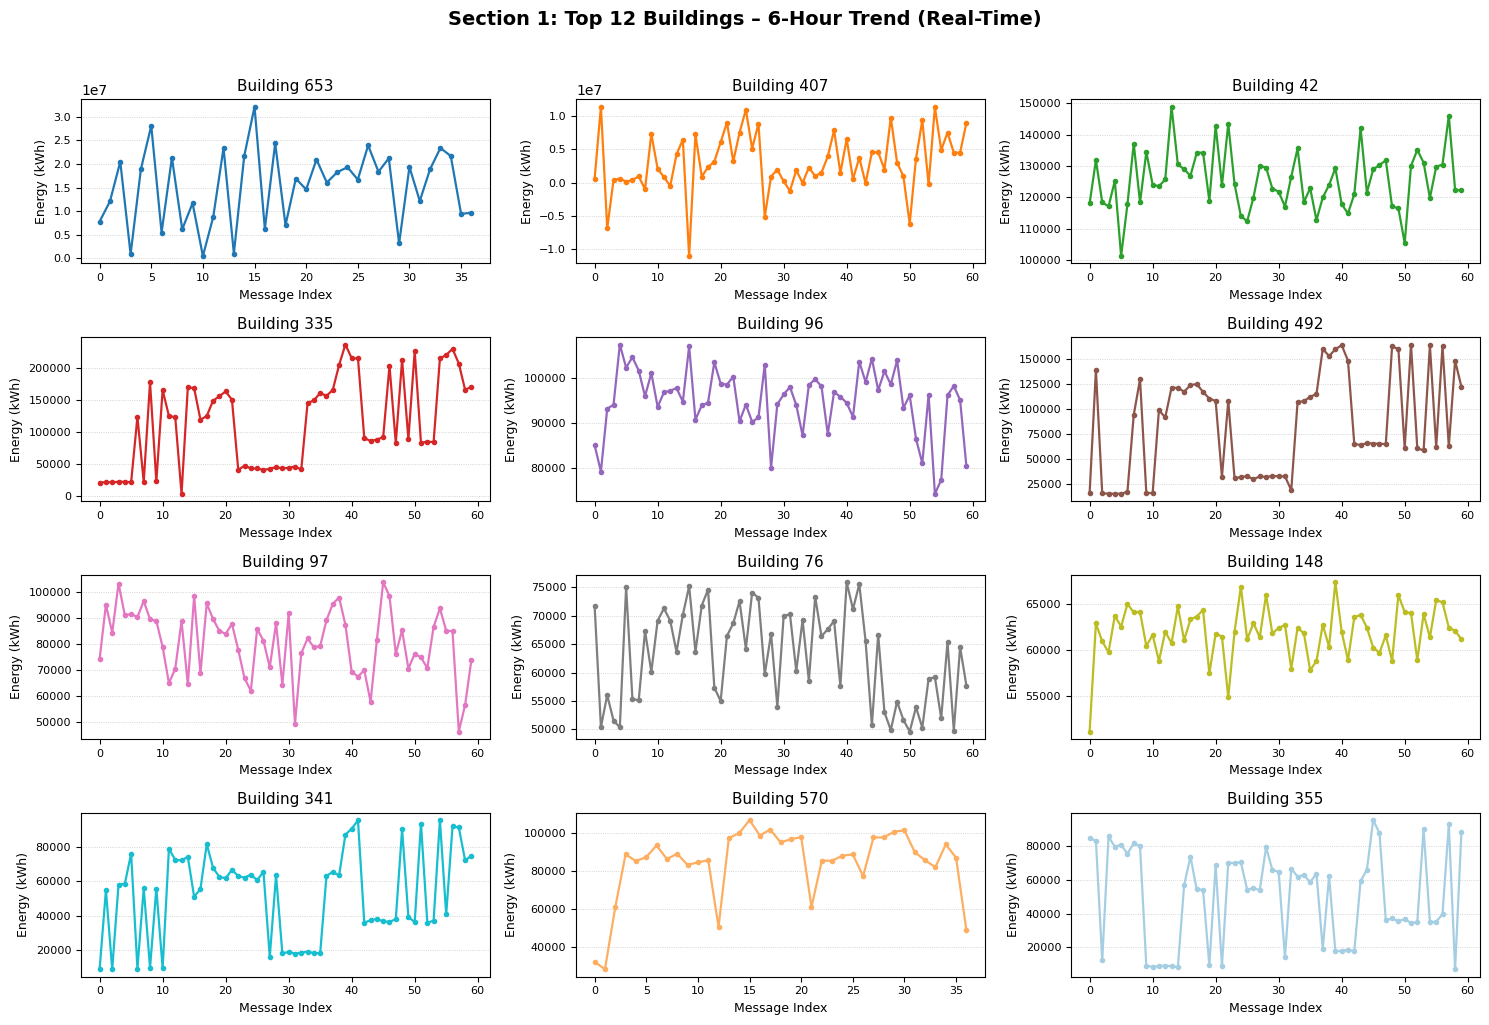

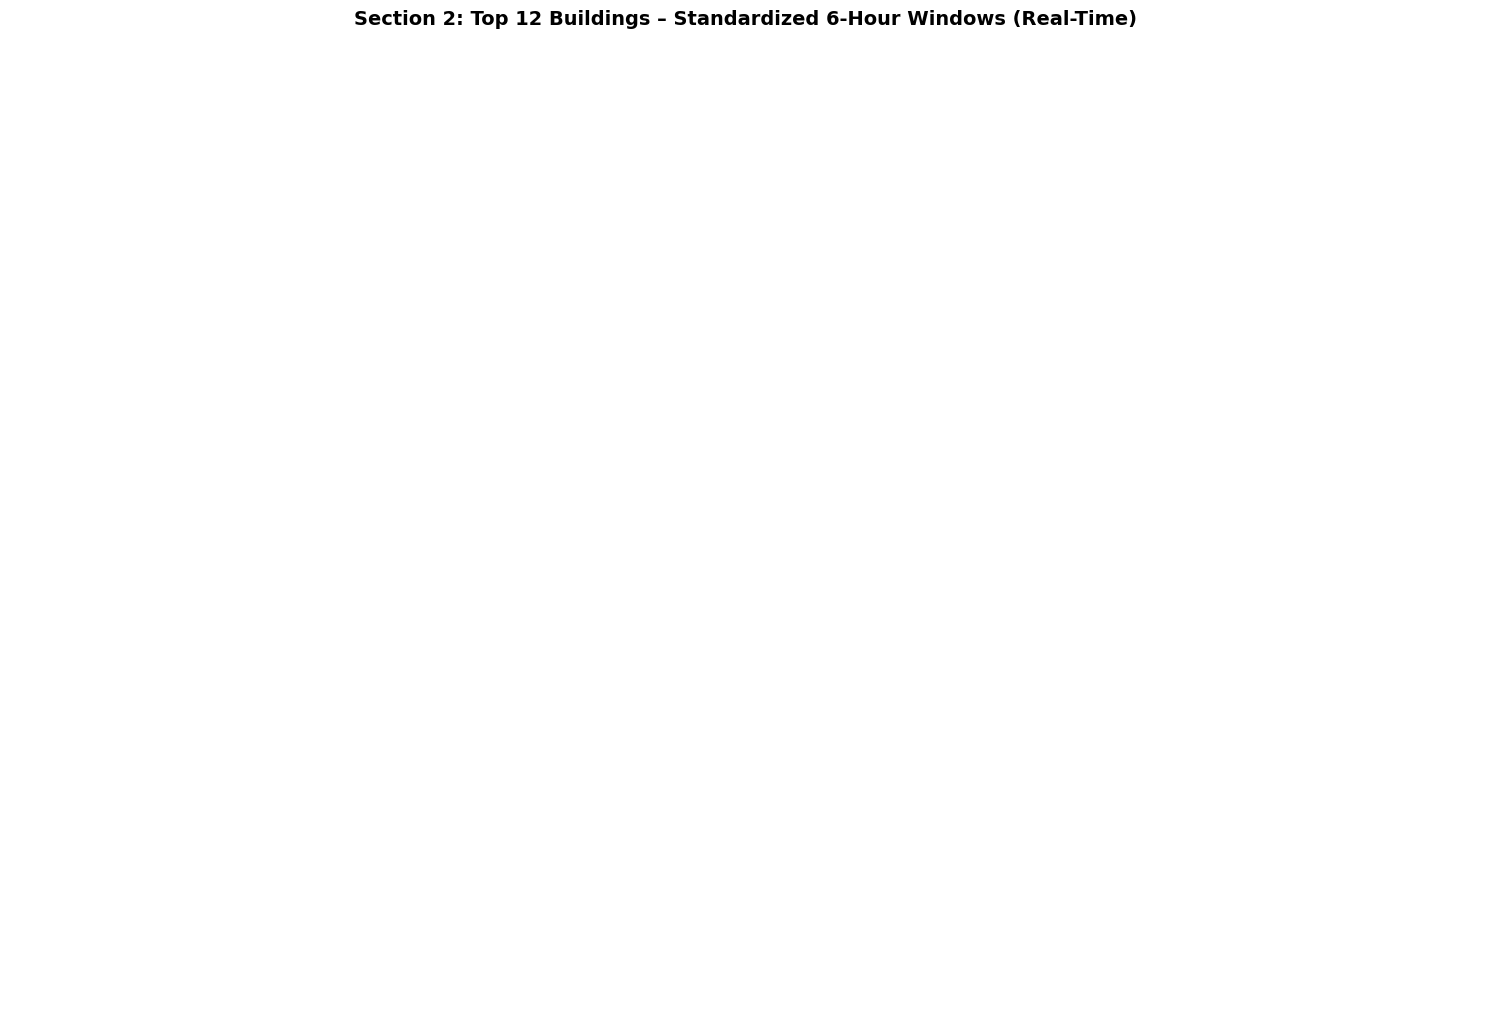

In [3]:
# =========================================================
#  2(6b) Real-Time Predicted 6 Hours Energy
# =========================================================

import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

try:
    from IPython.display import clear_output, display
    _ip_ok = True
except Exception:
    _ip_ok = False

from kafka3 import KafkaConsumer

# ---------- Runtime config ----------
BOOTSTRAP = "kafka:9092"
TOPIC_6B  = "sixhour_totals_stream"
GROUP_ID  = f"consumer_sixhour_live_{int(time.time())}"

POLL_MS     = 400            # Kafka poll timeout (ms)
REFRESH_HZ  = 1.0            # plot refresh cadence
TICK        = 1.0 / REFRESH_HZ
HISTORY_LEN = 60             # points kept per building
TOP_N       = 12             # number of buildings shown (two 4x3 grids)

COLOR = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
    "#bcbd22", "#17becf", "#fdae61", "#a6cee3"
]

# ---------- Buffers ----------
series = {}          # building_id -> deque of energy values
winlab = {}          # building_id -> deque of window labels (string)

def _coalesce(d: dict, *keys, default=None):
    for k in keys:
        if k in d and d[k] is not None:
            return d[k]
    return default

# ---------- Message handler ----------
def on_message(raw: bytes):
    try:
        msg = json.loads(raw.decode("utf-8"))
    except Exception:
        return

    try:
        bid   = int(_coalesce(msg, "building_id"))
        label = str(_coalesce(msg, "window_start", "window_label", default=""))
        val   = float(_coalesce(msg, "total_energy_6h", "sum_6hr", "kwh6h"))
    except Exception:
        # Skip if mandatory fields are missing
        return

    if bid not in series:
        series[bid] = deque(maxlen=HISTORY_LEN)
        winlab[bid] = deque(maxlen=HISTORY_LEN)

    # Append once per window (avoid dup spam)
    if not winlab[bid] or label != winlab[bid][-1]:
        winlab[bid].append(label)
        series[bid].append(val)

# ---------- Normalize 6-hour labels into 4 buckets ----------
STD_WINDOWS = ["00:00–06:00", "06:00–12:00", "12:00–18:00", "18:00–24:00"]

def normalize_window(label: str):
    if not label:
        return None
    sep = "–" if "–" in label else "-"
    start = label.split(sep)[0].strip()
    try:
        hour = int(start.split(":")[0])
    except Exception:
        return None
    if   0 <= hour <= 5:   return "00:00–06:00"
    if   6 <= hour <= 11:  return "06:00–12:00"
    if  12 <= hour <= 17:  return "12:00–18:00"
    if  18 <= hour <= 23:  return "18:00–24:00"
    return None

# ---------- Redraw both grids ----------
def redraw():
    if not series:
        return

    totals = {b: float(sum(series[b])) for b in series}
    top_b  = sorted(totals, key=totals.get, reverse=True)[:TOP_N]

    # Grid 1: Trend vs arrival index
    fig1, axes1 = plt.subplots(4, 3, figsize=(15, 10))
    axes1 = axes1.ravel()
    for i, bid in enumerate(top_b):
        ax = axes1[i]
        ys = list(series[bid]); xs = np.arange(len(ys))
        ax.cla()
        if ys:
            ax.plot(xs, ys, marker="o", linewidth=1.6, markersize=3, color=COLOR[i % len(COLOR)])
            ax.set_title(f"Building {bid}", fontsize=11)
            ax.set_xlabel("Message Index", fontsize=9)
            ax.set_ylabel("Energy (kWh)", fontsize=9)
            ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7)
            ax.tick_params(axis="both", labelsize=8)
        else:
            ax.axis("off")
    for j in range(len(top_b), len(axes1)):
        axes1[j].axis("off")
    fig1.suptitle("Section 1: Top 12 Buildings – 6-Hour Trend (Real-Time)", fontsize=14, fontweight="bold", y=1.02)
    fig1.tight_layout()

    # Grid 2: Average per normalized 6-hour window
    fig2, axes2 = plt.subplots(4, 3, figsize=(15, 10))
    axes2 = axes2.ravel()
    for i, bid in enumerate(top_b):
        ax = axes2[i]
        ys = list(series[bid])
        xs = [normalize_window(lbl) for lbl in winlab[bid]]
        ax.cla()
        if ys and any(xs):
            df_b = (pd.DataFrame({"window": xs, "energy": ys})
                    .dropna()
                    .groupby("window", as_index=False)
                    .mean(numeric_only=True))
            y_vals = [df_b.loc[df_b["window"] == w, "energy"].mean()
                      if w in df_b["window"].values else np.nan
                      for w in STD_WINDOWS]
            ax.plot(STD_WINDOWS, y_vals, marker="o", linewidth=1.6, color=COLOR[i % len(COLOR)])
            ax.set_title(f"Building {bid}", fontsize=11)
            ax.set_xlabel("6-Hour Window", fontsize=9)
            ax.set_ylabel("Avg Energy (kWh)", fontsize=9)
            plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
            ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7)
        else:
            ax.axis("off")
    for j in range(len(top_b), len(axes2)):
        axes2[j].axis("off")
    fig2.suptitle("Section 2: Top 12 Buildings – Standardized 6-Hour Windows (Real-Time)",
                  fontsize=14, fontweight="bold", y=1.02)
    fig2.tight_layout()

    if _ip_ok:
        clear_output(wait=True); display(fig1); display(fig2)
    else:
        plt.show()
    plt.close(fig1); plt.close(fig2)

# ---------- Kafka consumer loop ----------
consumer = KafkaConsumer(
    TOPIC_6B,
    bootstrap_servers=BOOTSTRAP,
    group_id=GROUP_ID,
    auto_offset_reset="earliest",
    enable_auto_commit=True,
    value_deserializer=lambda b: b,
    max_poll_records=1000,
)

print(f"[6b] Listening to '{TOPIC_6B}' … Ctrl+C to stop.")
try:
    while True:
        t0 = time.time()
        polled = consumer.poll(timeout_ms=POLL_MS) or {}
        for _, msgs in polled.items():
            for m in msgs:
                on_message(m.value)
        redraw()
        dt = time.time() - t0
        if dt < TICK: time.sleep(TICK - dt)
except KeyboardInterrupt:
    print("\n[6b] Stopped by user.")
finally:
    try: consumer.close()
    except: pass

#### **2(6b) Real-Time Predicted 6 Hours Energy**

- **Objective:** Continuously visualise six-hour aggregated energy usage for the top 12 buildings in real time.  
- **Source:** Kafka topic `sixhour_totals_stream`, published from Task 8(b).  
- **Data Fields:** `building_id`, `window_start/window_label`, `total_energy_6h/sum_6hr/kwh6h`.  
- **Approach:**  
  - Maintains rolling buffers (60 records) per building for recent data.  
  - Normalises window labels into standard 6-hour intervals (`00–06`, `06–12`, `12–18`, `18–24`).  
  - Generates two dynamic 4×3 grids:  
    1. **Trend Chart:** Live line plots showing real-time energy flow across messages.  
    2. **Window Chart:** Mean energy across fixed 6-hour windows for daily pattern recognition.  
- **Validation:** Ensured message decoding, handled duplicates, and verified stability of axis scaling.  
- **Outcome:** Delivers a clear dual view, both **temporal trend** and **time-window distribution**,for operational monitoring.


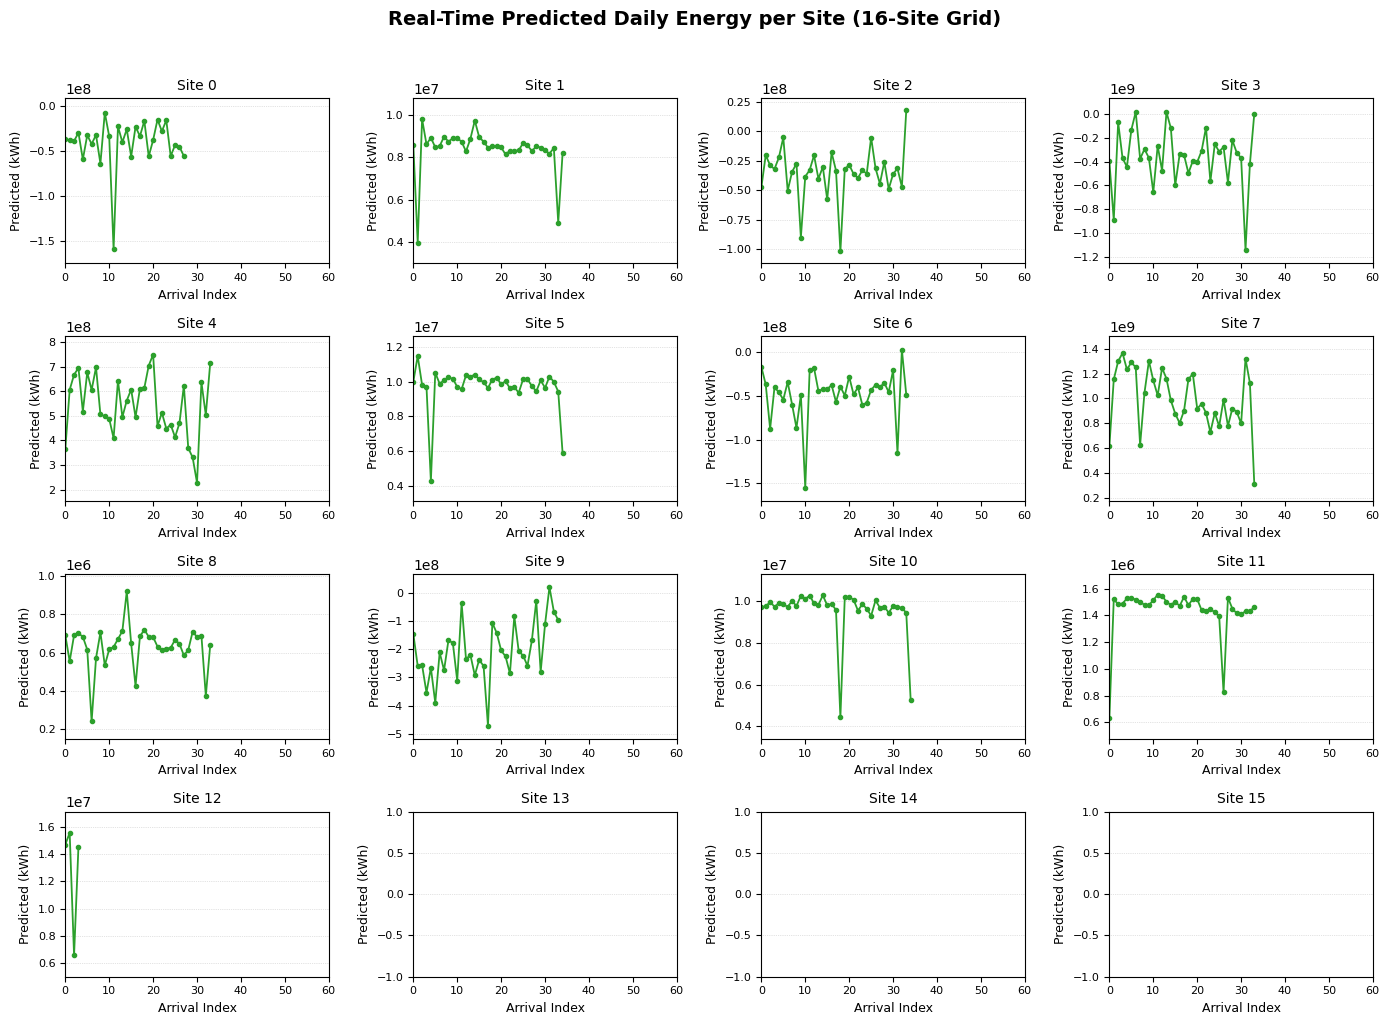

Heartbeat: local member_id was not recognized; this consumer needs to re-join
Heartbeat: local member_id was not recognized; this consumer needs to re-join


In [ ]:
# === LIVE 6(c): Daily site totals from Kafka -> 4x4 live line charts (safe for Jupyter) ===
import time, json
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import clear_output, display
from kafka3 import KafkaConsumer, errors as kerrors

# ---- Config (only change BOOTSTRAP if needed) ----
BOOTSTRAP = "kafka:9092"          # try "localhost:9092" if Jupyter isn't on the Docker network
TOPIC     = "daily_totals_stream"  # <-- matches your 8c writer
GROUP_ID  = f"site_daily_live_{int(time.time())}"

POLL_MS   = 500
REFRESH_HZ= 2.0
TICK      = 1.0 / REFRESH_HZ
HIST_LEN  = 60
SITE_IDS  = list(range(16))        # 0..15 as in your code
LINE_COLOR = "#2ca02c"             # green (only color change as requested)

# ---- Buffers ----
series = {sid: deque(maxlen=HIST_LEN) for sid in SITE_IDS}

def _get(d, *cands, default=None):
    for k in cands:
        if k in d and d[k] is not None:
            return d[k]
    return default

def on_message(b: bytes):
    """Decode JSON and push into per-site buffers. Tolerates field name variants."""
    try:
        msg = json.loads(b.decode("utf-8"))
    except Exception:
        return
    sid = _get(msg, "site_id", "siteId", "siteID")
    val = _get(msg, "total_energy_day", "total_energy", "sum_day", "kwh_day", "prediction")
    if sid is None or val is None:
        return
    try:
        sid = int(sid); val = float(val)
    except Exception:
        return
    if sid in series:
        series[sid].append(val)

def redraw():
    fig, axes = plt.subplots(4, 4, figsize=(14, 10))
    axes = axes.ravel()
    for ax, sid in zip(axes, SITE_IDS):
        ys = list(series[sid]); xs = np.arange(len(ys))
        ax.cla()
        if ys:
            ax.plot(xs, ys, marker="o", linewidth=1.3, markersize=3, color=LINE_COLOR)
            ax.set_xlim(0, HIST_LEN)
            ymin, ymax = float(min(ys)), float(max(ys))
            pad = 0.1 * max(abs(ymin), abs(ymax), 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)
        else:
            ax.set_xlim(0, HIST_LEN); ax.set_ylim(-1, 1)
        ax.set_title(f"Site {sid}", fontsize=10, pad=6)
        ax.set_xlabel("Arrival Index", fontsize=9)
        ax.set_ylabel("Predicted (kWh)", fontsize=9)
        ax.grid(axis="y", linestyle=":", linewidth=0.5, alpha=0.7)
        ax.tick_params(axis="both", which="major", labelsize=8)

    fig.suptitle("Real-Time Predicted Daily Energy per Site (16-Site Grid)",
                 y=1.02, fontsize=14, fontweight="bold")
    fig.tight_layout()
    clear_output(wait=True); display(fig); plt.close(fig)

# ---- Robust connect (prevents kernel crash if broker not ready) ----
retries = 12  # ~12 * 2s = 24s max
consumer = None
for i in range(retries):
    try:
        consumer = KafkaConsumer(
            TOPIC,
            bootstrap_servers=BOOTSTRAP,
            group_id=GROUP_ID,
            auto_offset_reset="latest",     # change to "earliest" to replay history
            enable_auto_commit=True,
            value_deserializer=lambda b: b,
            max_poll_records=1000,
        )
        break
    except kerrors.NoBrokersAvailable:
        clear_output(wait=True)
        print(f"[6c] Waiting for Kafka broker at {BOOTSTRAP} (attempt {i+1}/{retries}) …")
        time.sleep(2)

if consumer is None:
    raise RuntimeError(f"[6c] Could not connect to Kafka at {BOOTSTRAP}. "
                       f"Try BOOTSTRAP='localhost:9092' if Jupyter is outside Docker.")

print(f"[6c] Listening to '{TOPIC}' @ {BOOTSTRAP}, Ctrl+C to stop.")
try:
    while True:
        t0 = time.time()
        polled = consumer.poll(timeout_ms=POLL_MS) or {}
        for _, msgs in polled.items():
            for m in msgs:
                on_message(m.value)
        redraw()
        dt = time.time() - t0
        if dt < TICK:
            time.sleep(TICK - dt)
except KeyboardInterrupt:
    pass
finally:
    try: consumer.close()
    except Exception: pass
    print("[6c] Stopped.")

### **2(6c), Real-Time Predicted Daily Energy (16 Sites)**

- **Objective:** Stream and visualise live predictions of daily total energy across 16 monitored sites.  
- **Source:** Kafka topic `daily_totals_stream`, published from Task 8(c).  
- **Data Fields:** `site_id`, `total_energy_day/total_energy/sum_day/kwh_day/prediction`.  
- **Approach:**  
  - Consumes Kafka messages using `KafkaConsumer` with 2 Hz refresh rate.  
  - Stores last 60 values for each of 16 sites (IDs 0–15).  
  - Displays a **4×4 live grid** of line plots showing predicted kWh over message index.  
- **Features:** Auto-scaled y-axis for readability, gridlines for clarity, robust broker retry, and consistent labeling.  
- **Validation:** Verified field parsing, numeric conversions, and live refresh timing.  
- **Outcome:** Provides a dynamic, real-time dashboard for monitoring model predictions and detecting anomalies instantly.

## 3. Shortfall and excess per site

```
shortfall = predicted total energy per site  −  actual metered energy per site
```

The reconciliation problem: the predicted stream is keyed on `weather_ts`
derived event time, while the meters file carries its own `ts` column on the
original measurement scale. Both have to be normalised to the same daily
grain before the difference is meaningful, otherwise the chart shows a real
number computed from misaligned inputs, which is worse than showing nothing.

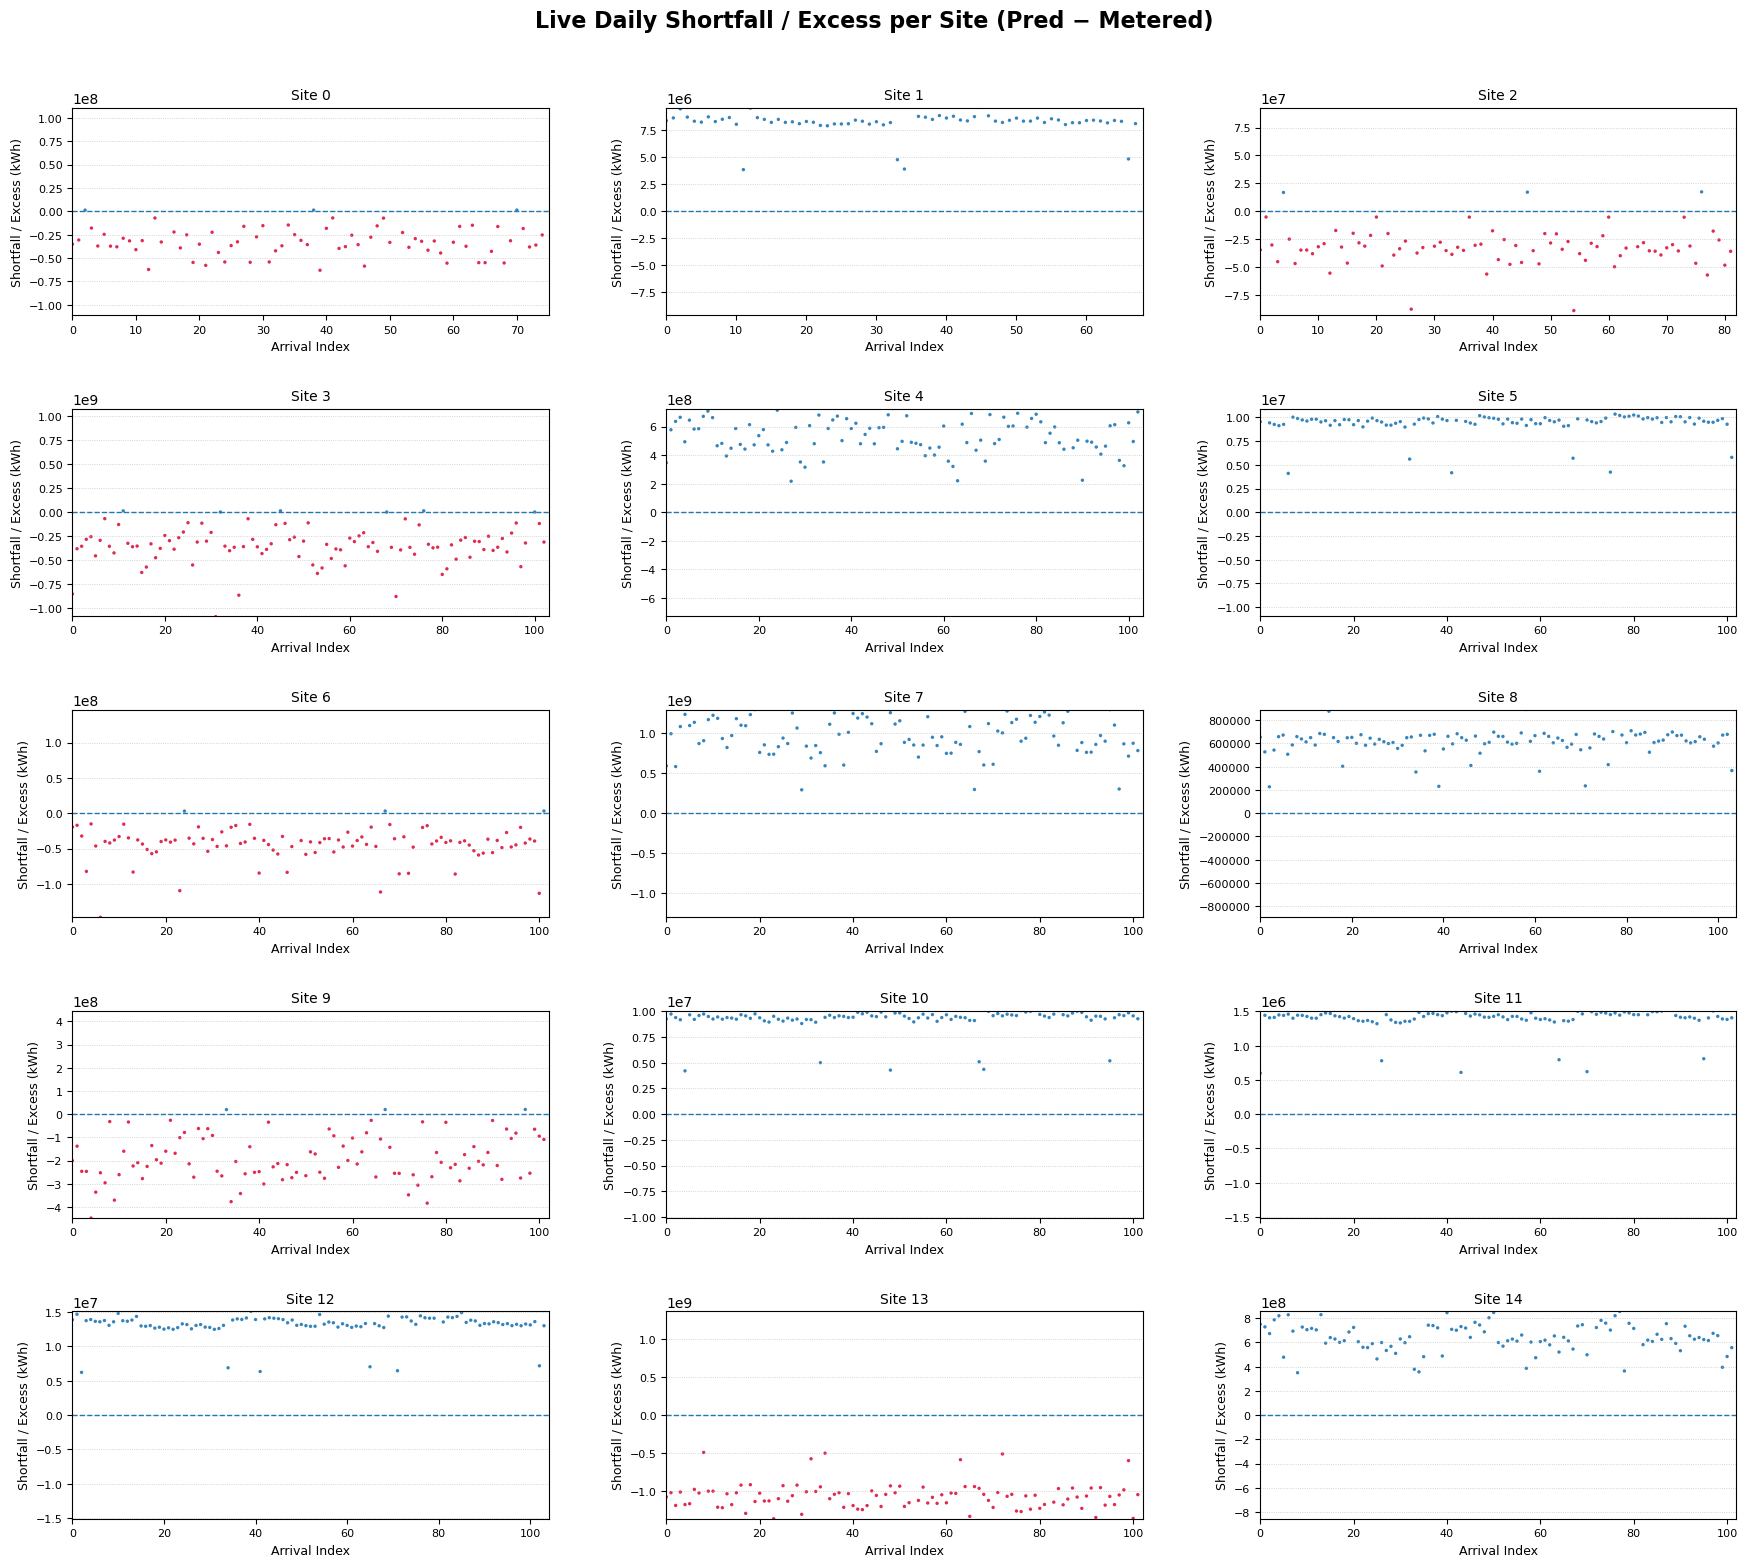

[3C] Listening LIVE to 'daily_totals_stream' @ kafka:9092 | Ctrl+C to stop.


[3C] Stopped by user.


In [3]:
# ========= A2B – Task 3C: Live Shortfall/Excess (non-blinking, live-only) =========
import time, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict, deque
from IPython.display import display
from kafka3 import KafkaConsumer, errors as kerrors
from pyspark.sql import functions as F, types as T

# -------------------- CONFIG --------------------
BOOTSTRAP   = "kafka:9092"          # use "localhost:9092" if Jupyter is outside Docker network
TOPIC       = "daily_totals_stream" # your Task 8c writer topic
HIST_LEN    = 6000                  # how many points to keep per site
POLL_MS     = 200                   # consumer.poll timeout (lower = more frequent)
REFRESH_HZ  = 2.0                   # UI refresh rate (plots/sec)
FALLBACK_ZERO_WHEN_NO_METER = True  # True: show dots even if no meter match yet

# -------------------- 1) Build METER lookup from new_meters.csv --------------------
METERS_PATH = "dataset/new_meters.csv"
meters_schema = T.StructType([
    T.StructField("building_id", T.IntegerType(),   True),
    T.StructField("meter_type",  T.StringType(),    True),
    T.StructField("ts",          T.TimestampType(), True),
    T.StructField("value",       T.DoubleType(),    True),
    T.StructField("row_id",      T.IntegerType(),   True),
])

meters_df = (
    spark.read
         .option("header", True)
         .schema(meters_schema)
         .csv(METERS_PATH)
         .filter(F.col("value").isNotNull())
)

# Daily totals per (building_id, day)  -> treat building_id as site_id
site_daily_meters = (
    meters_df
    .select(
        F.col("building_id").cast("int").alias("site_id"),
        F.to_date("ts").alias("day"),
        F.col("value").cast("double").alias("kwh")
    )
    .groupBy("site_id", "day")
    .agg(F.sum("kwh").alias("metered"))
)

meters_pdf = site_daily_meters.toPandas()
meters_pdf["day"] = meters_pdf["day"].astype(str)              # yyyy-mm-dd
meter_lookup = {(int(r.site_id), r.day): float(r.metered) for _, r in meters_pdf.iterrows()}
known_sites  = sorted({int(s) for s in meters_pdf["site_id"].unique()})

# 15 sites for 3x5 layout
SITE_IDS = list(range(16)) if set(range(16)).intersection(known_sites) else known_sites[:15]
if len(SITE_IDS) < 15:
    SITE_IDS = SITE_IDS + [None]*(15 - len(SITE_IDS))

# -------------------- 2) Buffers & helpers --------------------
hist  = {sid: deque(maxlen=HIST_LEN) for sid in SITE_IDS if sid is not None}
stats = defaultdict(int)

def _get(obj, *names, default=None):
    for n in names:
        if n in obj and obj[n] is not None:
            return obj[n]
    return default

def _daykey(obj):
    # accepts 'day', 'date', 'day_start', 'day_end'
    s = _get(obj, "day", "date", "day_start", "day_end")
    if not s: return None
    return str(s)[:10]  # yyyy-mm-dd from any ISO

# -------------------- 3) Kafka consumer (LIVE ONLY) --------------------
def make_live_consumer():
    # create unsubscribed consumer
    c = KafkaConsumer(
        bootstrap_servers=BOOTSTRAP,
        group_id=f"live_only_{int(time.time())}",  # fresh group → no committed offsets
        enable_auto_commit=False,
        auto_offset_reset="latest",                # if no commit, start at end
        max_poll_records=500
    )
    c.subscribe([TOPIC])
    # wait for partition assignment then jump to end
    while not c.assignment():
        c.poll(timeout_ms=100)
    c.seek_to_end()   # jump to tail on all assigned partitions
    return c

try:
    consumer = make_live_consumer()
except kerrors.NoBrokersAvailable:
    raise RuntimeError(f"[3C] Cannot connect to Kafka at {BOOTSTRAP}")

# -------------------- 4) Message handler --------------------
def handle_message(msg_bytes):
    try:
        obj = json.loads(msg_bytes.decode("utf-8"))
    except Exception:
        stats["decode_err"] += 1
        return

    sid  = _get(obj, "site_id", "siteId", "siteID")
    pred = _get(obj, "total_energy_day", "total_energy", "sum_day", "kwh_day", "prediction")
    if sid is None or pred is None:
        stats["skipped_no_fields"] += 1
        return

    try:
        sid  = int(sid)
        pred = float(pred)
    except Exception:
        stats["skipped_cast"] += 1
        return

    if sid not in hist:  # site not in our 15 slots
        stats["missed_site"] += 1
        return

    day_key = _daykey(obj)
    met = meter_lookup.get((sid, day_key))
    if met is None and not FALLBACK_ZERO_WHEN_NO_METER:
        stats["missed_no_meter"] += 1
        return

    diff = pred - (met or 0.0)
    hist[sid].append(diff)
    stats["matched"] += 1

# -------------------- 5) Figure (non-blinking, persistent display) --------------------
plt.ioff()
fig, axes = plt.subplots(5, 3, figsize=(18, 16))
axes = axes.ravel()

def redraw():
    for ax, sid in zip(axes, SITE_IDS):
        ax.cla()
        if sid is None:
            ax.set_axis_off()
            continue

        ys = list(hist[sid])
        xs = np.arange(len(ys))
        ax.axhline(0, linestyle="--", linewidth=1)

        if ys:
            # color by sign
            colors = np.where(np.array(ys) < 0, "crimson", "#1f77b4")
            ax.scatter(xs, ys, s=6, c=colors, alpha=0.9, edgecolors="none")
            # percentile scale to keep axes stable but responsive
            yabs = max(1.0, float(np.percentile(np.abs(ys), 98)))
            ax.set_ylim(-yabs, yabs)
            ax.set_xlim(max(0, len(ys) - HIST_LEN), len(ys))
        else:
            ax.set_ylim(-1, 1)
            ax.set_xlim(0, 10)

        ax.set_title(f"Site {sid}", fontsize=10, pad=6)
        ax.set_xlabel("Arrival Index", fontsize=9)
        ax.set_ylabel("Shortfall / Excess (kWh)", fontsize=9)
        ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7)
        ax.tick_params(axis="both", labelsize=8)

    fig.suptitle("Live Daily Shortfall / Excess per Site (Pred − Metered)",
                 fontsize=16, fontweight="bold", y=0.99)
    fig.tight_layout(pad=2.6)

display_handle = display(fig, display_id=True)  # persistent handle, no clear_output

# -------------------- 6) Live loop --------------------
tick = 1.0 / REFRESH_HZ
print(f"[3C] Listening LIVE to '{TOPIC}' @ {BOOTSTRAP}, Ctrl+C to stop.\n")
try:
    while True:
        t0 = time.time()
        polled = consumer.poll(timeout_ms=POLL_MS) or {}
        for _, msgs in polled.items():
            for m in msgs:
                stats["msgs"] += 1
                handle_message(m.value)
        redraw()
        display_handle.update(fig)  # update in place (no flicker)
        dt = time.time() - t0
        if dt < tick:
            time.sleep(tick - dt)
except KeyboardInterrupt:
    print("\n[3C] Stopped by user.")
finally:
    try: consumer.close()
    except Exception: pass
    plt.close(fig)

#### **3, Live Shortfall/Excess Energy per Site (Pred − Metered)**

**What it does:**  
This visualisation continuously monitors and displays the **difference between predicted and metered daily energy** for multiple sites in real time. The calculation used is:  
\[
\text{Shortfall/Excess} = \text{Predicted Energy} - \text{Metered Energy}
\]  
Each site’s data is consumed live from the Kafka topic `daily_totals_stream`, while actual metered values are retrieved from the `new_meters.csv` dataset through Spark aggregation.


**What it visualises:**  
- A **3×5 grid of scatter plots**, where each subplot represents one site (e.g., Site 0–Site 15).  
- The **X-axis** shows the message arrival index (real-time updates).  
- The **Y-axis** shows the energy difference in kWh (shortfall or excess).  
- A **horizontal dashed line at zero** indicates perfect prediction alignment.


**What can be understood from the plot:**  
- Dots **above the zero line** indicate **excess prediction** (predicted > metered).  
- Dots **below the zero line** indicate **shortfall** (predicted < metered).  
- A stable, narrow distribution around zero implies good model accuracy and low error.  
- Large deviations or consistent bias above/below zero highlight **model drift** or **data inconsistencies**.


**Colour meanings:**  
- **Blue Dots:** Energy excess, prediction higher than actual measured energy. 
- **Red Dots:** Energy shortfall, prediction lower than actual measured energy. 
-  **Dashed Line (Zero):** Perfect balance between predicted and metered values.


**Summary:**  
This live, non-blinking visualisation acts as a **real-time performance dashboard**, allowing engineers to evaluate model reliability, detect anomalies, and monitor prediction behaviour across multiple energy sites simultaneously.

---

## End to end

Historical meter readings trained a gradient-boosted pipeline; that same
fitted artefact now scores a live weather feed, and the forecast reaches an
operator dashboard within seconds of the reading arriving, with the
forecast error surfaced per site so the operator can see where to trust it.